In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix, roc_curve



In [143]:
raw_data = pd.read_csv("./survey_lung_cancer.csv").set_axis(list(range(16)), axis=1)

cont_attr = list(range(1,15))
min_max_scaler = MinMaxScaler()
x = raw_data[cont_attr].values
x_scaled = min_max_scaler.fit_transform(x)

normalized = pd.DataFrame(x_scaled, columns=cont_attr, index=raw_data.index)
raw_data[cont_attr] = normalized

ord_enc = OrdinalEncoder(dtype = np.int32)
raw_data[15] = ord_enc.fit_transform(raw_data[[15]])

ord_enc = OrdinalEncoder(dtype = np.int32)
raw_data[0] = ord_enc.fit_transform(raw_data[[0]])

Y = np.array(raw_data.pop(15))
X = np.array(raw_data)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)


In [144]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dt.fit(X_train, Y_train)
score = dt.score(X_test, Y_test)


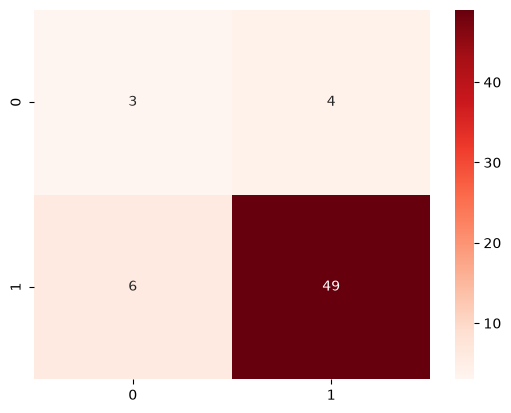

In [145]:
Y_pre = dt.predict(X_test)
acc = accuracy_score(Y_test, Y_pre)
prec = precision_score(Y_test, Y_pre)
f1 = f1_score(Y_test, Y_pre)
con_mat = confusion_matrix(Y_test, Y_pre)#normalize="true"

sns.heatmap(con_mat, annot=True, cmap="Reds")#fmt=".2%"
plt.show()

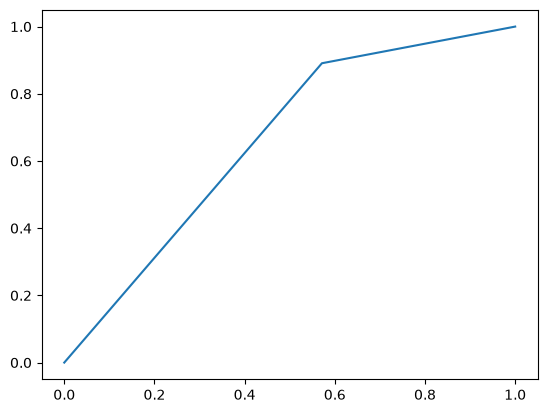

In [146]:
F_pos, T_pos, _ = roc_curve(Y_test, Y_pre)
plt.plot(F_pos, T_pos)
plt.show()